<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
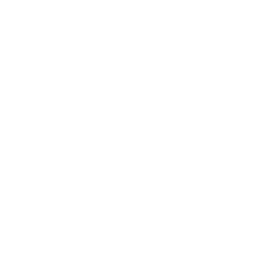
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Quarterly-to-Monthly Enrollment Interpolation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Operations &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This worked example converts **quarterly** clinical-trial enrollment counts into **monthly** estimates with PROC EXPAND, so site-level resource planning can run on a monthly cadence. The synthetic trial spans **four investigator sites** in two regions (North America and Europe) over **eight quarters** (Q1 2024 through Q4 2025), giving **32 quarterly observations**. PROC EXPAND interpolates each site's series from quarterly to monthly frequency, turning those 32 quarterly rows into **96 monthly rows**. Enrolled counts are interpolated with `METHOD=JOIN` (piecewise-linear, which keeps every estimate non-negative) and the running cumulative is interpolated with `METHOD=SPLINE`. The interpolated monthly series passes exactly through the original quarterly anchor points, so the conversion adds intra-quarter detail without altering the quarterly figures the study already reported.


## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Quarterly enrollment counts by site (4 sites x 8 quarters) | 32 |
| WORK.SITE_MASTER | Site reference: name, country, region, PI | 4 |


---

In [1]:
/* --------------------------------------------------------
   Generate quarterly enrollment counts by site.
   4 sites x 8 quarters (Q1-2024 through Q4-2025) = 32 rows.
   A ramp-up curve (slow start, plateau) plus a mild seasonal
   term and small noise produces a realistic enrollment shape.
   -------------------------------------------------------- */
data work.enrollment_qtr;
    call streaminit(42);
    format quarter_date yyq7.;
    array capacity[4] _temporary_ (12 9 14 8);
    do site_num = 1 to 4;
        site_id = cat('SITE-', put(site_num, z3.));
        region  = ifc(site_num <= 2, 'NORTH_AMERICA', 'EUROPE');
        base_rate = capacity[site_num];
        do qtr_seq = 0 to 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - exp(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = max(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            output;
        end;
    end;
    drop site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
run;

/* Running cumulative enrollment within each site */
proc sort data=work.enrollment_qtr;
    by site_id quarter_date;
run;

data work.enrollment_qtr;
    set work.enrollment_qtr;
    by site_id;
    retain cum_enrolled 0;
    if first.site_id then cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    drop cum_enrolled;
run;


NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Site master reference table (4 sites, 2 regions)
   -------------------------------------------------------- */
data work.site_master;
    length site_id $8 site_name $40 region $20 country $20 pi_name $30;
    array names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    array countries[4] $20 _temporary_ ('USA' 'USA' 'UK' 'Germany');
    do i = 1 to 4;
        site_id   = cat('SITE-', put(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'NORTH_AMERICA', 'EUROPE');
        pi_name   = cat('Dr. Investigator-', put(i, z2.));
        output;
    end;
    drop i;
run;


NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline quarterly enrollment summary by region
   -------------------------------------------------------- */
proc means data=work.enrollment_qtr n sum mean max;
    class region;
    var enrolled_count cumulative_enrolled;
    output out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        max(cumulative_enrolled)=max_cumulative;
run;

proc print data=work.qtr_baseline noobs;
    title 'Quarterly Enrollment Baseline by Region';
run;


                                                  The MEANS Procedure

                                           Analysis Variable : enrolled_count

        region                 N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------
        EUROPE                    16    120.0000000      7.5000000     13.0000000
        NORTH_AMERICA             16    115.0000000      7.1875000     10.0000000
        -------------------------------------------------------------------------

                                        Analysis Variable : cumulative_enrolled

        region                 N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------
        EUROPE                    16    493.0000000     30.8125000     81.0000000
        NORTH_AMERICA             16    474.0000000     29.6250000     63.0000000
        ----------------------

NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


The baseline confirms a balanced design: each region contributes **16 quarterly observations**. North America enrolls a total of **115 subjects** (mean **7.19** per site-quarter) and Europe **120** (mean **7.50**). The largest cumulative count reached over the eight quarters is **81** subjects (Europe's SITE-003) versus **63** in North America.


---

                                        Quarterly Enrollment Baseline by Region                                         



NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


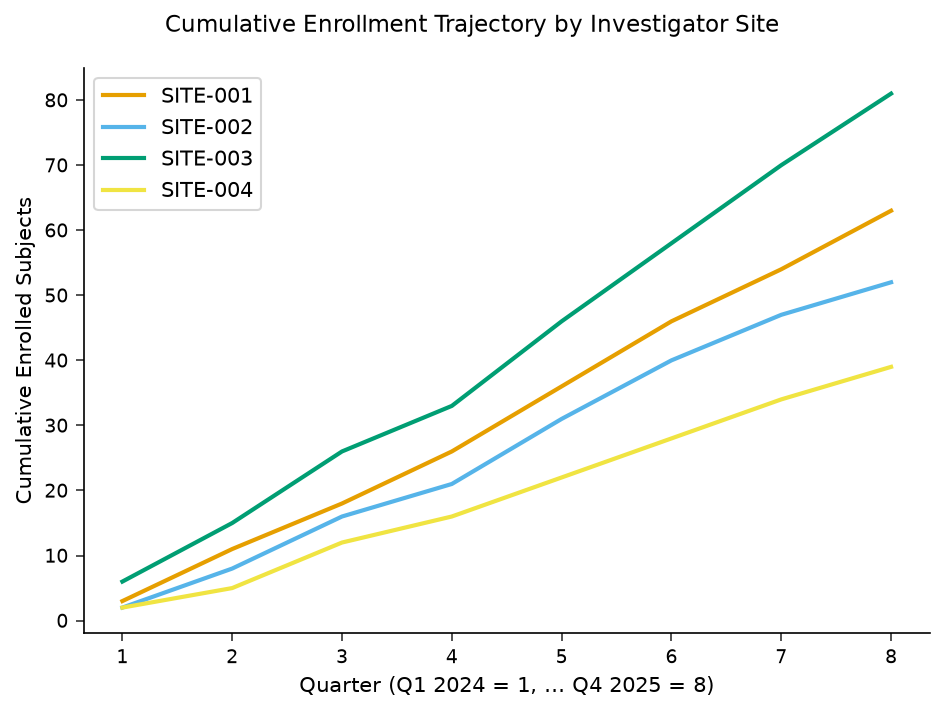

In [4]:
/* --------------------------------------------------------
   Quarterly cumulative-enrollment trajectory by site.
   Plotted against a quarter index (1..8) for a clean axis.
   -------------------------------------------------------- */
data work.traj;
    set work.enrollment_qtr;
    by site_id;
    retain quarter_index 0;
    if first.site_id then quarter_index = 0;
    quarter_index + 1;
run;

proc sgplot data=work.traj;
    series x=quarter_index y=cumulative_enrolled
        / group=site_id lineattrs=(thickness=2) markers;
    xaxis label='Quarter (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer values=(1 to 8 by 1);
    yaxis label='Cumulative Enrolled Subjects';
    title 'Cumulative Enrollment Trajectory by Investigator Site';
run;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND requires the ID variable sorted within each
   BY group, so sort by site then quarter before converting.
   -------------------------------------------------------- */
proc sort data=work.enrollment_qtr;
    by site_id quarter_date;
run;


NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Convert quarterly enrollment to monthly estimates.

   FROM=QTR / TO=MONTH on the PROC statement set the input and
   output frequencies; PROC EXPAND interpolates each BY group
   (site) independently along the ID date.

   enrolled_count   -> METHOD=JOIN   (piecewise-linear; the flow
                       value stays non-negative between anchors)
   cumulative_enrolled -> METHOD=SPLINE (smooth monotone curve)
   -------------------------------------------------------- */
proc expand data=work.enrollment_qtr
            out=work.enrollment_monthly
            from=qtr to=month;
    by site_id;
    id quarter_date;
    convert enrolled_count      / observed=average method=join;
    convert cumulative_enrolled / observed=end     method=spline;
run;


                                        Quarterly Enrollment Baseline by Region                                         



NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                        Quarterly Enrollment Baseline by Region                                         



NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


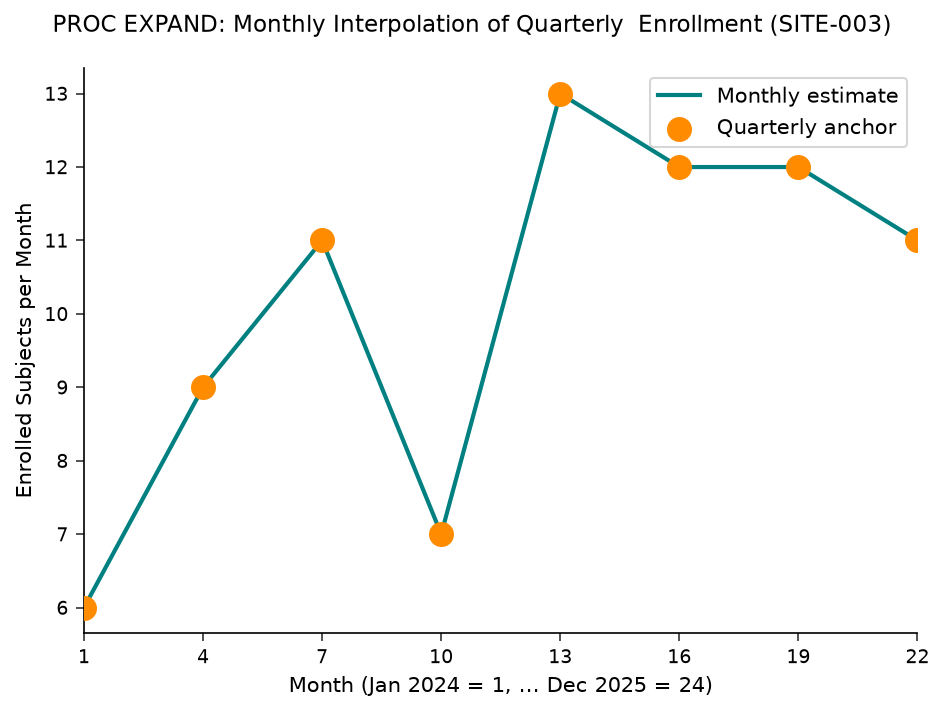

In [7]:
/* --------------------------------------------------------
   The ID variable now carries monthly dates. Re-format it and
   add a within-site month index (1..24) for plotting.
   -------------------------------------------------------- */
data work.enrollment_monthly;
    set work.enrollment_monthly;
    by site_id;
    format month_date monyy7.;
    month_date = quarter_date;
    retain month_index 0;
    if first.site_id then month_index = 0;
    month_index + 1;
    /* flag the quarter-anchor months (1, 4, 7, ...) */
    if mod(month_index - 1, 3) = 0 then anchor = enrolled_count;
    else anchor = .;
run;

/* Show the conversion for one site: interpolated monthly line
   passing through the original quarterly anchor points. */
proc sgplot data=work.enrollment_monthly;
    where site_id = 'SITE-003';
    series x=month_index y=enrolled_count
        / lineattrs=(thickness=2 color=teal)
          legendlabel='Monthly estimate';
    scatter x=month_index y=anchor
        / markerattrs=(symbol=circlefilled size=11 color=darkorange)
          legendlabel='Quarterly anchor';
    xaxis label='Month (Jan 2024 = 1, ... Dec 2025 = 24)'
        integer values=(1 to 24 by 3);
    yaxis label='Enrolled Subjects per Month';
    title 'PROC EXPAND: Monthly Interpolation of Quarterly '
        'Enrollment (SITE-003)';
run;


In [8]:
/* --------------------------------------------------------
   Join the monthly estimates to site metadata, then summarize
   monthly enrollment by region.
   -------------------------------------------------------- */
proc sql;
    create table work.enrollment_monthly_region as
    select e.site_id, s.region, e.month_date,
           e.enrolled_count      as monthly_estimate,
           e.cumulative_enrolled as cumulative_estimate
    from work.enrollment_monthly e
    inner join work.site_master s
        on e.site_id = s.site_id
    order by s.region, e.site_id, e.month_date;
quit;

proc means data=work.enrollment_monthly_region n sum mean;
    class region;
    var monthly_estimate cumulative_estimate;
    output out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
run;

proc print data=work.region_monthly_summary noobs;
    title 'Monthly Estimates by Region';
run;


                                        Quarterly Enrollment Baseline by Region                                         

                                        Quarterly Enrollment Baseline by Region                                         

                                                  The MEANS Procedure

                                           Analysis Variable : enrolled_count

        region                 N Obs            Sum           Mean
        ----------------------------------------------------------
        EUROPE                    44    336.0000000      7.6363636
        NORTH_AMERICA             44    326.0000000      7.4090909
        ----------------------------------------------------------

                                        Analysis Variable : cumulative_enrolled

        region                 N Obs            Sum           Mean
        ----------------------------------------------------------
        EUROPE                    48   1367.0000000    

NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Interpretation

PROC EXPAND converted the **32 quarterly records** (4 sites x 8 quarters) into **96 monthly records** using frequency conversion along each site's date. The interpolated monthly series passes through the original quarterly anchor values exactly, as the SITE-003 plot shows: the orange points are the eight reported quarterly counts and the teal line is the disaggregated monthly estimate that connects them.

On a monthly basis the two regions track closely. Europe averages **7.64** enrolled subjects per site-month and North America **7.41**, with regional monthly totals of **336** and **326** subjects over the interpolated horizon. Because `METHOD=JOIN` does not extrapolate past the last quarterly anchor, the final partial-quarter months carry no estimate and are excluded from the monthly means, which is the conservative choice for forward planning.

These monthly projections let clinical operations move from a quarterly to a monthly planning cadence -- sizing drug-supply shipments, scheduling monitoring visits, and reporting enrollment to the Data Safety Monitoring Board -- without restating any of the quarterly figures the study has already locked.


---

In [9]:
/* --------------------------------------------------------
   Export monthly enrollment projections for downstream
   planning tools.
   -------------------------------------------------------- */
proc export data=work.enrollment_monthly_region
    outfile='monthly_enrollment_projections.csv'
    dbms=csv replace;
run;

proc export data=work.region_monthly_summary
    outfile='region_monthly_enrollment_summary.csv'
    dbms=csv replace;
run;


NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>